In [5]:
# Using https://github.com/DeepLearnPhysics/spine-workshop-2026/blob/main/basics/larcv/LArCV_visualization.ipynb for reference to look at LARCV files. 
import larcv
import ROOT
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
import spine
from spine.io.dataset.larcv import LArCVDataset
import h5py


fname = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/electron_NDLAr_10MeVto15GeV_1008TEST.2001.LARCV.root' # Change this path if you are not on NERSC
#fname = 'LOCAL_PATH'
f = ROOT.TFile(fname)
f.ls()

TFile**		/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/electron_NDLAr_10MeVto15GeV_1008TEST.2001.LARCV.root	
 TFile*		/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/electron_NDLAr_10MeVto15GeV_1008TEST.2001.LARCV.root	
  KEY: TTree	particle_pcluster_tree;2	pcluster tree [current cycle]
  KEY: TTree	particle_pcluster_tree;1	pcluster tree [backup cycle]
  KEY: TTree	sparse3d_pcluster_tree;1	pcluster tree
  KEY: TTree	sparse3d_pcluster_semantics_tree;1	pcluster_semantics tree
  KEY: TTree	cluster3d_pcluster_tree;1	pcluster tree
  KEY: TTree	cluster3d_pcluster_dedx_tree;1	pcluster_dedx tree


In [6]:
import uproot

tree = uproot.open(fname)
tree.keys()

['particle_pcluster_tree;2',
 'particle_pcluster_tree;1',
 'sparse3d_pcluster_tree;1',
 'sparse3d_pcluster_semantics_tree;1',
 'cluster3d_pcluster_tree;1',
 'cluster3d_pcluster_dedx_tree;1']

In [7]:
import numpy as np
tree = f.Get("cluster3d_pcluster_tree")
print('Number of entries', tree.GetEntries())

for entry in range(tree.GetEntries()):
    tree.GetEntry(entry)
    event = tree.cluster3d_pcluster_branch
    clusters = event.as_vector()
    print("Number of clusters = ", len(clusters))
    cluster_sizes = []
    for c in clusters:
        cluster_sizes.append(c.as_vector().size())
    print(np.sum(np.array(cluster_sizes)))

Number of entries 50
Number of clusters =  14648
28190
Number of clusters =  1791
3476
Number of clusters =  9355
18194
Number of clusters =  15687
30623
Number of clusters =  10347
20140
Number of clusters =  12642
23804
Number of clusters =  8169
15925
Number of clusters =  14786
28938
Number of clusters =  15126
29168
Number of clusters =  4451
8724
Number of clusters =  2576
5110
Number of clusters =  11052
21005
Number of clusters =  14797
28575
Number of clusters =  10570
20607
Number of clusters =  4476
8529
Number of clusters =  1001
1865
Number of clusters =  15348
30220
Number of clusters =  7295
14216
Number of clusters =  1630
3077
Number of clusters =  5355
10565
Number of clusters =  13979
27274
Number of clusters =  13262
25844
Number of clusters =  15214
29595
Number of clusters =  2988
6104
Number of clusters =  14604
30543
Number of clusters =  11702
22578
Number of clusters =  8178
15556
Number of clusters =  1069
2125
Number of clusters =  10030
19502
Number of clus

In [8]:
tree = f.Get("particle_pcluster_tree")
print('Number of entries', tree.GetEntries())
energy_init_values = []
start_x = []
start_y = []
start_z = []

for entry in range(tree.GetEntries()):
    tree.GetEntry(entry)
    event = tree.particle_pcluster_branch
    #print("Event:", event)
    particles = event.as_vector()
    #print("Number of particles = ", len(particles))
    energy_init_values.append(particles[0].energy_init())
    start_x.append(particles[0].x())
    start_y.append(particles[0].y())
    start_z.append(particles[0].z())

print("Energy init values:", energy_init_values)
print("Start x:", start_x)
print("Start y:", start_y)
print("Start z:", start_z)
energy_init_values = np.array(energy_init_values)
start_x = np.array(start_x)
start_y = np.array(start_y)
start_z = np.array(start_z)
    

Number of entries 50
Energy init values: [13546.148874120987, 1564.6433881218124, 8619.411838918946, 14868.582980498371, 9846.479258010422, 11638.395452373927, 7705.870696580472, 13661.68526100735, 14445.72294771218, 4116.704713667451, 2478.6434609080643, 10010.18025804656, 13773.255591414785, 10080.51003247676, 3956.5023554015925, 812.0674328160816, 14683.185470521972, 6767.771676208916, 1414.323603421605, 4989.190063896968, 13339.658573464081, 12487.377221174944, 14467.26674999312, 2917.8554024927703, 14202.94603615523, 11067.767575439491, 7449.831694352057, 1049.7772989813263, 9329.58538618214, 847.9076557592653, 1667.8361755273384, 2743.768143975916, 9153.781099688615, 1385.7205321818265, 11835.317434208706, 13494.070513462962, 11334.864694680251, 12724.479699779155, 4567.427147296952, 6970.305134659445, 14917.60039013589, 12345.766139998635, 13656.367513394887, 13268.835969607406, 145.6610682364279, 9396.63705836161, 4309.043980500445, 6355.045852830034, 2434.4214835718444, 12599.

Number of entries 50
Entry: 189160
Number of sparse3d =  15750
Total event value sums: [7672.68636097]
Position x start: [127.22740969457936, 194.18920427067405, 40.921096685390694, 1.488039879468488, 80.72616346118048, -342.6211822476844, -339.6451024887465, -154.75614746475185, -296.86395595401973, -229.1581414381908, 6.696179457609105, 7.068189427476682, -22.692608161898534, -22.692608161898534, 3.3480897288045526, -25.29667795096975, -22.320598192031866, -22.320598192031866, -25.29667795096975, 7.068189427476682, 15.996428704289428, 4.0921096685387965, 9.67225921654699, 4.0921096685387965, 4.8361296082730405, 11.160299096015478, 2.232059819202732, -264.4990885755742, 8.55622930694517, 8.55622930694517, 8.55622930694517, 8.55622930694517, 8.55622930694517, 7.440199397343349, 0.0, 7.812209367210926, 8.184219337077593, 8.184219337077593, 8.55622930694517, 7.812209367210926, 8.184219337077593, 7.812209367210926, 8.184219337077593, 7.812209367210926, 2.976079758936976, 8.55622930694517,

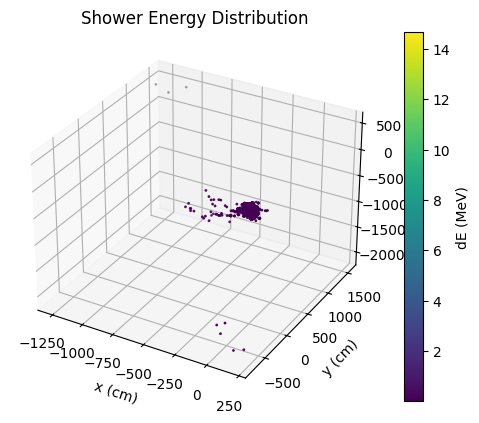

In [15]:
import numpy as np
tree = f.Get("sparse3d_pcluster_tree")
print('Number of entries', tree.GetEntries())
total_event_value_sum = []
pos_x_start = []
pos_y_start = []
pos_z_start = []


for entry in range(tree.GetEntries()):
    if entry != 6:
        continue
    tree.GetEntry(entry)
    print("Entry:", tree.GetEntry(entry))
    event = tree.sparse3d_pcluster_branch
    #print("Event:", event)
    #print("Event Meta:", event.meta())
    event_meta = event.meta()
    #print("Event meta().dump():", event.meta().dump())
    sparse3d = event.as_vector()
    #print("Sparse3D:", sparse3d)
    print("Number of sparse3d = ", len(sparse3d))
    sparse3d_ids = []
    sparse3d_values = []
    idx = 0
    for s in sparse3d:
        sid = s.id()
        position_x = event_meta.pos_x(sid)
        position_y = event_meta.pos_y(sid)
        position_z = event_meta.pos_z(sid)
        pos_x_start.append(position_x)
        pos_y_start.append(position_y)
        pos_z_start.append(position_z)
        #print("Position:", position_x, position_y, position_z)
        sparse3d_values.append(s.value())
        idx += 1
        #print("Value:", s.value())
        #break
    #print(np.array(sparse3d_ids))
    total_event_value_sum.append(np.sum(np.array(sparse3d_values)))

print("Total event value sums:", np.array(total_event_value_sum))
print("Position x start:", pos_x_start)
print("Position y start:", pos_y_start)
print("Position z start:", pos_z_start) 
print("Sparse3D values:", sparse3d_values)
pos_x_start = np.array(pos_x_start)
pos_y_start = np.array(pos_y_start) 
pos_z_start = np.array(pos_z_start)

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(pos_x_start,pos_y_start, pos_z_start, c=sparse3d_values, cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

In [6]:
# Check against original edep-sim hdf5 file: 
import h5py 
# Get shower data function 
def get_shower_data(sim_h5, event_id):

    parse_var='event_id'
    seg_var='segments'     

    traj_spill_mask = sim_h5['trajectories'][:][parse_var]==event_id
    seg_spill_mask = sim_h5[seg_var][:][parse_var]==event_id
    event_mask = sim_h5['events'][:][parse_var]==event_id

    traj = sim_h5['trajectories'][traj_spill_mask]
    seg = sim_h5[seg_var][seg_spill_mask]
    event = sim_h5['events'][event_mask]

    return traj, seg, event

In [7]:
edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/CONVERT2H5/electron_NDLAr_10MeVto15GeV_TEST5.1002.CONVERT2H5.hdf5"
#edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/ELECTRON_SAMPLES/CONVERT2H5/TEST/electron_positron_10MeVto2GeV.8947.CONVERT2H5.hdf5"
sim_h5 = h5py.File(edep_sim_file, 'r')
event_energy = []
total_seg_energy = []

num_events = len(np.unique(sim_h5['events']['event_id']))
for event_id in range(num_events):
    traj, seg, events = get_shower_data(sim_h5, event_id)
    event_energy.append(events['E_start'][0])
    total_seg_energy.append(np.sum(seg['dE']))


event_energy = np.array(event_energy)
total_seg_energy = np.array(total_seg_energy)
print("Total segment energy:", total_seg_energy)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/CONVERT2H5/electron_NDLAr_10MeVto15GeV_TEST5.1002.CONVERT2H5.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [8]:
total_event_value_sum = np.array(total_event_value_sum)

diff_event_val_sum_total_seg_energy = total_event_value_sum - total_seg_energy
diff_energy_init_values_event_energy = energy_init_values - event_energy
#print("Event energy:", event_energy)
#print("Energy init values:", energy_init_values)
print("Difference between total event value sum and total segment energy:", diff_event_val_sum_total_seg_energy)
print("Difference between energy init LARCV and event energy edep-sim:", diff_energy_init_values_event_energy)

Difference between total event value sum and total segment energy: [-2.64560030e+02 -7.06252365e+03 -2.40802951e+03 -1.03656682e+04
 -2.37755979e+03 -9.77845432e+03 -9.64552854e+03 -3.02602219e+03
 -2.80812180e+03 -2.10539475e+03  1.60187942e+03 -1.11065949e+04
 -1.09925002e+04 -9.18792014e+03 -5.58765061e+03 -6.44303635e+03
 -2.11731613e+03  4.24358183e+02 -5.81135861e+03 -6.00987033e+03
 -1.43300852e+03 -2.63959445e+03 -3.78011789e+03 -7.65819260e+03
 -6.39376193e+03 -5.02086936e+03  2.85713368e-05 -3.84893967e+03
 -5.28223606e+03  2.06228433e+03 -7.66180393e+03 -7.19892502e+03
 -8.60755393e+03 -4.96220920e+03 -9.92439768e+03 -7.83006563e+02
 -6.05839084e+03 -1.54067063e+03 -1.06028108e+04 -1.03282492e+04
  1.32207290e+03 -5.24539278e+02  8.09126738e+02 -9.70509493e+02
 -7.92514865e+03 -2.89394259e+02 -8.93759981e+02  9.62967558e+02
 -2.44375704e+02 -8.77348654e+03]
Difference between energy init LARCV and event energy edep-sim: [-4.69315419e-05 -4.24032365e-04 -1.72599337e-04 -1.679

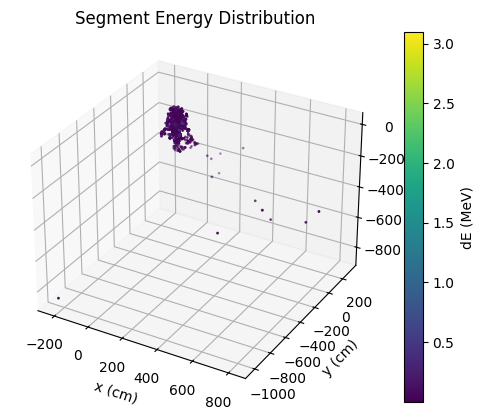

[[0.9748668 ]
 [1.6086833 ]
 [1.7011578 ]
 ...
 [0.03253315]
 [0.26575103]
 [0.14156896]]
Segment positions: [[-2.7143600e-04 -1.8697858e-04 -2.8926247e-01]
 [-1.2720362e-03 -9.4990840e-04 -9.7455508e-01]
 [-3.3100238e-03 -1.8503999e-03 -1.7913272e+00]
 ...
 [-8.4567353e-02 -3.9647952e-02 -2.7333839e+01]
 [ 1.3718651e-02 -8.3633959e-03 -5.8886886e-01]
 [ 2.4713743e-02 -1.7725833e-02 -5.9973520e-01]]


In [9]:
traj, seg, events = get_shower_data(sim_h5, 26)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(seg['x'], seg['y'], seg['z'], c=seg['dE'], cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Segment Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()
print(np.array([seg['dE']]).T)
segment_positions = np.array([seg['x'], seg['y'], seg['z']]).T 
print("Segment positions:", segment_positions)

In [10]:
# Access LARCV file with parser
DATA_PATH = fname
ENTRY = "["+str(10)+"]" # Change this to access different entries in the LARCV file.
NUM_WORKERS = 4

cfg = """
base:
  verbosity: info
io:
  loader:
    batch_size: 1
    shuffle: False
    num_workers: NUM_WORKERS
    collate_fn: all
    dataset:
      name: larcv
      file_keys: DATA_PATH
      entry_list: ENTRY
      schema:
        input_data:
          parser: sparse3d
          sparse_event: sparse3d_pcluster
        particles:
          parser: particle
          particle_event: particle_pcluster
          sparse_event: sparse3d_pcluster
        meta:
          parser: meta
          sparse_event: sparse3d_pcluster
""".replace('DATA_PATH', DATA_PATH).replace('ENTRY', str(ENTRY)).replace('NUM_WORKERS', str(NUM_WORKERS))

print(cfg)


base:
  verbosity: info
io:
  loader:
    batch_size: 1
    shuffle: False
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root
      entry_list: [10]
      schema:
        input_data:
          parser: sparse3d
          sparse_event: sparse3d_pcluster
        particles:
          parser: particle
          particle_event: particle_pcluster
          sparse_event: sparse3d_pcluster
        meta:
          parser: meta
          sparse_event: sparse3d_pcluster



In [11]:
import yaml
import sys 
sys.path.append("/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine")
import spine
from spine.driver import Driver

cfg = yaml.safe_load(cfg)



In [12]:
driver = Driver(cfg)
data = driver.process()


 ██████████   ██████████    ███   ███       ██   ███████████
███        █  ██       ███   █    █████     ██   ██         
  ████████    ██       ███  ███   ██  ████  ██   ██████████ 
█        ███  ██████████     █    ██     █████   ██         
 ██████████   ██            ███   ██       ███   ███████████

Release version: 0.10.3

$CUDA_VISIBLE_DEVICES=None

Configuration processed at: Linux login11 6.4.0-150600.23.73_15.0.14-cray_shasta_c #1 SMP Tue Oct 21 20:32:25 UTC 2025 (89d3c98) x86_64 x86_64 x86_64 GNU/Linux

base: {verbosity: info, world_size: 0, seed: 1776711920}
io:
  loader:
    batch_size: 1
    shuffle: false
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root
      entry_list: [10]
      schema:
        input_data: {parser: sparse3d, sparse_event: sparse3d_pcluster}
        particles: {parser: particle, particle_

Will load 1 file(s):
 - /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root

Loading tree sparse3d_pcluster
Loading tree particle_pcluster

Total number of entries in the file(s): 50

Total number of entries selected: 1



In [13]:
event_id = 0

# Get true energy:
particles = data['particles'][event_id]
print("Particles:", particles[0])
true_energy = particles[0].energy_init
true_KE = particles[0].p
print("True energy:", true_energy)
print("True kinetic energy:", true_KE)

# Get positions and energies for each filled voxel:
positions = data['input_data'][event_id][:,1:4]
energy_per_voxel = data['input_data'][event_id][:,4]
input_data_full = data['input_data'][event_id]

print("Input data:", input_data_full)
print("Positions (voxel):", positions)
print("Energy per voxel:", energy_per_voxel)

# Get positions for each filled voxel (actual x, y, z coordinates):
meta = data['meta'][event_id]
positions_cm = meta.to_cm(positions, center=True)
print("Positions (cm):", positions_cm/10)
print(np.array([[i] for i in energy_per_voxel]))


Particles: Particle(id=0, mct_index=65535, mcst_index=65535, group_id=np.int64(0), interaction_id=np.int64(0), nu_id=np.int64(-1), interaction_primary=np.int64(1), group_primary=np.int64(1), parent_id=np.int64(0), children_id=array([], dtype=int64), track_id=0, parent_track_id=0, ancestor_track_id=np.int64(0), pid=np.int64(1), pdg_code=-11, parent_pdg_code=-11, ancestor_pdg_code=-11, num_voxels=702, shape=0, energy_init=1107.3664340896853, energy_deposit=520.9133911132812, distance_travel=566.2025896974413, creation_process='2::22', parent_creation_process='2::22', ancestor_creation_process='2::22', t=1000.0, end_t=2903.4024729999996, parent_t=1000.0, ancestor_t=1000.0, position=array([13440.5, 13440.5, 13440.5], dtype=float32), end_position=array([13461.714, 13451.577, 13300.913], dtype=float32), parent_position=array([13440.5, 13440.5, 13440.5], dtype=float32), ancestor_position=array([13440.5, 13440.5, 13440.5], dtype=float32), first_step=array([-2.4793347e+13, -2.4793347e+13, -2.47

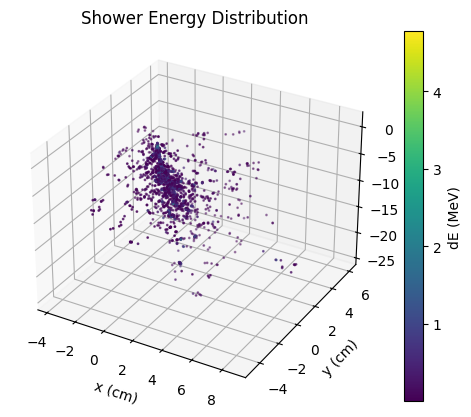

In [14]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(positions_cm[:,0]/10,positions_cm[:,1]/10,positions_cm[:,2]/10, c=energy_per_voxel, cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

In [16]:
# Copied from https://github.com/NERSC/nersc-dl-multigpu/blob/main/utils/YParams.py

import yaml

class ParseYAML():
    """ Yaml file parser """
    def __init__(self, yaml_filename, config_name, print_params=False):
        self._yaml_filename = yaml_filename
        self._config_name = config_name
        self.params = {}

        if print_params:
            print("------------------ Configuration ------------------")

        with open(yaml_filename) as _file:

            config = yaml.safe_load(_file)[config_name]
            for key, val in config.items():
                if print_params: print(key, val)
                if val =='None': val = None

                self.params[key] = val
                self.__setattr__(key, val)

        if print_params:
            print("---------------------------------------------------")

    def __getitem__(self, key):
        return self.params[key]

    def __setitem__(self, key, val):
        self.params[key] = val
        self.__setattr__(key, val)
    
    def __contains__(self, key):
        return (key in self.params)

    def update_params(self, config):
        for key, val in config.items():
            self.params[key] = val
            self.__setattr__(key, val)

    def log(self):
        print("------------------ Configuration ------------------")
        print("Configuration file: "+str(self._yaml_filename))
        print("Configuration name: "+str(self._config_name))
        for key, val in self.params.items():
            print(str(key) + ' ' + str(val))
        print("---------------------------------------------------")

In [22]:
# Modeled after: https://github.com/NERSC/nersc-dl-multigpu/blob/main/utils/data_loader.py

from curses import meta

import torch
from torch.utils.data import DataLoader, Dataset, get_worker_info
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import numpy as np
import sys
import subprocess
import os
import time
import pandas as pd
from scipy import stats
import csv

import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/src/')
import spine
from spine.io.dataset.larcv import LArCVDataset
from spine.io.sample import RandomSequenceBatchSampler, DistributedProxySampler
import yaml
import ROOT


def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])
try: 
    import h5py
except ImportError:
    install('h5py')
    import h5py

import glob

# Get data loader
def get_data_loader(params, data_location, distributed, train=True, test=False):
    """Function to get the data loader for training/validation/testing."""
    mode = 'train' if train else 'valid' if not test else 'test'

    dataset = ShowerDataset(params, data_location, mode=mode)
    batch_size = int(params.local_batch_size if train else params.local_valid_batch_size if not test else params.local_test_batch_size)
    # define a sampler for distributed training using DDP
    #if train == True:
    #    sampler = RandomSequenceBatchSampler(dataset=dataset, batch_size=batch_size, seed=params.random_seed, drop_last=True)
    #    if distributed == True:
    #        if not dist.is_available():
    #            raise RuntimeError("Requires distributed package to be available")
    #        num_replicas = dist.get_world_size()
    #        rank = dist.get_rank()
    #        sampler = DistributedProxySampler(sampler, num_replicas=num_replicas, rank=rank)
    #else:
    #    sampler = DistributedSampler(dataset, shuffle=False, drop_last=True) if distributed else None
    # Back to simpler sampler for now ...
    sampler = DistributedSampler(dataset, shuffle=False, drop_last=True) if distributed else None


    dataloader = DataLoader(dataset,
                            batch_size=batch_size,
                            num_workers=params.num_data_workers,
                            shuffle=(sampler is None and train), # Don't shuffle validation/test data
                            sampler=sampler,
                            collate_fn=shower_collate_fn,
                            drop_last=True,
                            persistent_workers=True,
                            prefetch_factor=4,
                            pin_memory= torch.cuda.is_available(), # unclear whether this helps ...
                            timeout=600) # timeout to prevent hanging

    return dataloader, sampler

segments_event_data_dtype = np.dtype([
    ('dE', np.float32),  # Energy deposit
    ('x', np.float32),   # X coordinate
    ('y', np.float32),   # Y coordinate
    ('z', np.float32)    # Z coordinate
])

# Dataset batch class to allow for pinned memory
#class ShowerCustomBatch:
#    def __init__(self, batch):
#        """Combine multiple samples into a batch (custom)."""
#        #coords_list = []
#        #features_list = []
#        data_list = []
#        labels_list = []
#        ve_frac_list = []
#        mg_frac_list = []
#        oob_frac_list = []
#        start_pos_list = []
#        rot_mat_list = []
#
#        for batch_idx, (data, label, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat) in enumerate(batch):
#            # Set batch index
#            batch_data = data.clone()
#            #print("Batch data shape:", batch_data.shape)
#            batch_data[:, 0] = batch_idx  # Set batch index to the first column
#
#            data_list.append(batch_data)
#
#            labels_list.append(label)
#            ve_frac_list.append(VE_frac)
#            mg_frac_list.append(MG_frac)
#            oob_frac_list.append(OOB_frac)
#            start_pos_list.append(start_pos)
#            rot_mat_list.append(rot_mat)
#
#        # Concatenate all coordinates and features into single tensors
#        self.inputs = torch.cat(data_list, dim=0)
#        self.targets = torch.stack(labels_list, dim=0).reshape(-1, 1) # ESSENTIAL -- ensures output and labels are same shape
#        self.ve_frac = torch.stack(ve_frac_list, dim=0).reshape(-1, 1)
#        self.mg_frac = torch.stack(mg_frac_list, dim=0).reshape(-1, 1)
#        self.oob_frac = torch.stack(oob_frac_list, dim=0).reshape(-1, 1)
#        self.start_pos = torch.stack(start_pos_list, dim=0) # Shape (B, 3)
#        self.rot_mat = torch.stack(rot_mat_list, dim=0) # Shape (
#
#        #print("Batched data:", batched_data)
#
#        #return batched_data, batched_labels, batched_ve_frac, batched_mg_frac, batched_oob_frac, batched_start_pos, batched_rot_mat
#    
#    # custom memory pinning method on custom type
#    def pin_memory(self):
#        self.inputs = self.inputs.pin_memory()
#        self.targets = self.targets.pin_memory()
#        self.ve_frac = self.ve_frac.pin_memory()
#        self.mg_frac = self.mg_frac.pin_memory()
#        self.oob_frac = self.oob_frac.pin_memory()
#        self.start_pos = self.start_pos.pin_memory()
#        self.rot_mat = self.rot_mat.pin_memory()
#        return self

def shower_collate_fn(batch): 
    """Collate function to combine multiple samples into a batch."""
    #coords_list = []
    #features_list = []
    data_list = []
    labels_list = []
    ve_frac_list = []
    mg_frac_list = []
    oob_frac_list = []
    start_pos_list = []
    rot_mat_list = []
    idx_list = []

    for batch_idx, (data, label, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat, idx) in enumerate(batch):
        # Set batch index
        batch_data = data.clone()
        #print("Batch data shape:", batch_data.shape)
        batch_data[:, 0] = batch_idx  # Set batch index to the first column

        data_list.append(batch_data)

        labels_list.append(label)
        ve_frac_list.append(VE_frac)
        mg_frac_list.append(MG_frac)
        oob_frac_list.append(OOB_frac)
        start_pos_list.append(start_pos)
        rot_mat_list.append(rot_mat)
        idx_list.append(idx)

    # Concatenate all coordinates and features into single tensors
    batched_data = torch.cat(data_list, dim=0)
    batched_labels = torch.stack(labels_list, dim=0).reshape(-1, 1) # ESSENTIAL -- ensures output and labels are same shape
    batched_ve_frac = torch.stack(ve_frac_list, dim=0).reshape(-1, 1)
    batched_mg_frac = torch.stack(mg_frac_list, dim=0).reshape(-1, 1)
    batched_oob_frac = torch.stack(oob_frac_list, dim=0).reshape(-1, 1)
    batched_start_pos = torch.stack(start_pos_list, dim=0) # Shape (B, 3)
    batched_rot_mat = torch.stack(rot_mat_list, dim=0) # Shape (B, 3, 3)
    batched_idx = torch.stack(idx_list, dim=0).reshape(-1, 1) 

    #print("Batched data:", batched_data)

    return batched_data, batched_labels, batched_ve_frac, batched_mg_frac, batched_oob_frac, batched_start_pos, batched_rot_mat, batched_idx

    #return ShowerCustomBatch(batch)

class ShowerDataset(Dataset):
         
    def __init__(self, params, data_location, mode='train'):

        """
        Args:
            params:                Parameters from yaml file
            data_location:         Path to dataset directory
            mode:                  'train' | 'valid' | 'test' 
        """

        self.mode = mode
        self.num_workers = params.num_data_workers
       
        self._file_dir = data_location
        # Set num_files for train/validation/test based on mode
        self._num_files_train = params.train_files
        self._num_files_val = params.val_files
        self._num_files_test = params.test_files
        self._set_dataset_file_list()  # Get list of files in dataset directory
        #self._larcv_dataset = LArCVDataset(file_keys=self._file_list, schema=params.schema, dtype="float32")
        #print("File list:",self._file_list)
        self._set_events_per_file()  # Get number of events per file + file indices

        self._detector_active_regions = np.array(params.detector_active_regions)
        self._RANDOM_SEED = int(params.random_seed)
        self._voxel_size = np.array(params.voxel_size)
        self._min_visible_energy = params.min_visible_energy  # For numerical stability in MinkowskiEngine (Minimum energy target) 
        self._inner_wall_fv_cut = params.inner_wall_fv_cut  # Fiducial volume cut in cm on inner walls (modules)
        self._ndlar_fv_cut = params.ndlar_fv_cut # Turn on extra FV cut on start position for ND-LAr? 
        self._outer_wall_fv_cut = params.outer_wall_fv_cut # Extra FV cut -- outer walls of full detector
        self._ds_wall_fv_cut = params.ds_wall_fv_cut # Extra FV cut -- downstream wall in z
        self._train_logE = params.train_logE  # Whether to take log of energy for training targets (for better training stability)

        self._ndlar_nue_profile = params.ndlar_nue_profile # just look at ndlar nu-e scatter-like showers

        # Get min and max bounds for each detector module
        self._min_bounds = self._detector_active_regions[:, 0, :] # Shape (M, 3) where M is the number of detector modules/active volumes
        self._max_bounds = self._detector_active_regions[:, 1, :] # Shape (M, 3) where M is the number of detector modules/active volumes

        # Set min/max coordinates and number of voxels
        self._min_xyz = np.array([np.min(self._detector_active_regions[:, :, 0]), 
                                  np.min(self._detector_active_regions[:, :, 1]),
                                  np.min(self._detector_active_regions[:, :, 2])])
        self._max_xyz = np.array([np.max(self._detector_active_regions[:, :, 0]),
                                  np.max(self._detector_active_regions[:, :, 1]),
                                  np.max(self._detector_active_regions[:, :, 2])])
        #print(f"Max coordinates: {self._max_xyz}")
        #print(f"Min coordinates: {self._min_xyz}")
        self._num_voxels = np.ceil((self._max_xyz - self._min_xyz) / self._voxel_size).astype(int)


        # Set random seeds for reproducibility
        # Use local generators vs. global to avoid interference between workers and encourage reproducibility
        #self._train_rng = np.random.default_rng(self._RANDOM_SEED)
        #np.random.seed(self._RANDOM_SEED)
        #torch.manual_seed(self._RANDOM_SEED)
        self._epoch = 0
        #self._train_rng = np.random.default_rng(self._RANDOM_SEED)
        self._train_rng = None

        # Set torch device
        #self._device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        #print(f"Using device: {self._device}")
        #torch.device(self._device)

        if self._ndlar_nue_profile == True:
            #print("Using ND-LAr nue profile for start direction sampling.")
            self._nue_profile_file = params.nue_profile_file
            df = pd.read_csv(self._nue_profile_file)
            nue_start_dir_x = df['start_dir_x']
            nue_start_dir_y = df['start_dir_y']
            nue_start_dir_z = df['start_dir_z']
            self._nue_start_dir_x_kde = stats.gaussian_kde(nue_start_dir_x)
            self._nue_start_dir_y_kde = stats.gaussian_kde(nue_start_dir_y)
            self._nue_start_dir_z_pareto_params = stats.pareto.fit(-nue_start_dir_z) # Flip z to fit to pareto
            #print("Fitted KDE for nue start dir x and y, and fitted Pareto distribution for nue start dir z with parameters:", self._nue_start_dir_z_pareto_params)

        self._fixed_augmentation_mode = False
        self._fixed_start_pos = None
        self._fixed_rotation_matrix = None
        self._last_fixed_aug_transformed_segments = None
        self._last_fixed_aug_all_energy_points = None
        self._last_fixed_aug_visible_points_mask = None

    def __len__(self):
        return np.sum(self._events_per_file)

    def __getitem__(self, idx):

        file_idx, event_local_idx = self._decode_idx(idx)  # Decode the global index into file and event indices
        
        #print(f"Loading file: {h5_file_name}, File index: {file_idx}, Event local index: {event_local_idx}")  # Debugging line to check which file and event is being loaded
        #print(f"Event global index: {idx}")  # Debugging line to check global index being loaded

        '''with h5py.File(h5_file_name, 'r') as h5_file:  # Open the HDF5 file
            file_events = h5_file['events']  # Access the events dataset
            file_segments = h5_file['segments']
            file_segments_refs = h5_file['segments_ref']

            event = file_events[event_local_idx]
            event_id = int(event['event_id'])
            segments = file_segments[file_segments_refs[event_id]]

            true_KE_initial = float(np.sqrt(np.sum(np.square(event['pxyz_start']))))

            # Same for train/validation/test now
            rng = self._get_deterministic_rng_per_event(idx)
            #print(f"Event ID: {idx}, RNG state: {rng.bit_generator.state}")  # Debugging line to check RNG state for each event
            vis_segs, ve_frac, mg_frac, oob_frac, start_pos, rot_mat = self._get_filtered_segments(rng, segments, true_KE_initial, self._min_visible_energy)'''

        '''# Accessing LARCV files using SPINE parsers
        DATA_PATH = self._file_list[file_idx]
        ENTRY = "["+str(event_local_idx)+"]" # Change this to access different entries in the LARCV file.
        NUM_WORKERS = 0

        cfg = """
            base:
              verbosity: warning
            io:
              loader:
                batch_size: 1
                shuffle: False
                num_workers: NUM_WORKERS
                collate_fn: all
                dataset:
                  name: larcv
                  file_keys: DATA_PATH
                  entry_list: ENTRY
                  schema:
                    input_data:
                      parser: sparse3d
                      sparse_event: sparse3d_pcluster
                    particles:
                      parser: particle
                      particle_event: particle_pcluster
                      sparse_event: sparse3d_pcluster
                    meta:
                      parser: meta
                      sparse_event: sparse3d_pcluster
            """.replace('DATA_PATH', DATA_PATH).replace('ENTRY', str(ENTRY)).replace('NUM_WORKERS', str(NUM_WORKERS))
            
        cfg = yaml.safe_load(cfg)
        driver = Driver(cfg)
        data = driver.process()'''
        initial_time = time.time()
        h5_file_name = self._file_list[file_idx]
        with h5py.File(h5_file_name, 'r') as h5_file:
            '''data = self._larcv_dataset[idx]''' # if just using idx, need to make sure idx is deterministics -- added sorted() to glob.glob of file dir
            post_access_data_time = time.time()
            true_KE_initial = float(h5_file['ke_initial'][event_local_idx])  # Access the true KE initial for the event

            # Get start and end voxels
            voxels_flat = h5_file['voxels_flat']  # Access the flat voxel array
            voxels_start = int(h5_file['voxels_offsets'][event_local_idx])
            voxels_end = int(h5_file['voxels_offsets'][event_local_idx + 1])
            event_voxels = voxels_flat[voxels_start:voxels_end]  # Get the voxel array for the event
            positions_cm = np.array(event_voxels[:, :3])  # Get the positions in cm
            energy_per_voxel = np.array(event_voxels[:, 3])  # Get the energy per voxel
        #print(len(self._larcv_dataset))  # Debugging line to check total number of events in dataset
        #print(f"Loaded event {idx} from file {self._file_list[file_idx]} with event file index {event_local_idx}")  # Debugging line to confirm event loading

        # Assume one event loaded at a time
        ''''particles = data['particles']
        true_KE_initial = float(particles[0].p)

        # Get positions and energies for each filled voxel:
        energy_per_voxel = data['input_data'].features
        energy_per_voxel = np.array([i for i in energy_per_voxel])
        positions = data['input_data'].coords
        meta = data['meta']
        positions_cm = np.array(meta.to_cm(positions, center=True))'''
        pre_augment_time=time.time()

        # Same for train/validation/test now
        rng = self._get_deterministic_rng_per_event(idx)
        #print(f"Event ID: {idx}, RNG state: {rng.bit_generator.state}")  # Debugging line to check RNG state for each event
        # Use fixed augmentation if visualization mode is enabled
        if self._fixed_augmentation_mode and self._fixed_start_pos is not None:
            vis_segs, ve_frac, mg_frac, oob_frac, start_pos, rot_mat = self._get_filtered_segments(
                rng, positions_cm, energy_per_voxel, true_KE_initial, self._min_visible_energy,
                fixed_start_pos=self._fixed_start_pos, fixed_rotation_matrix=self._fixed_rotation_matrix
            )
        else:
            vis_segs, ve_frac, mg_frac, oob_frac, start_pos, rot_mat = self._get_filtered_segments(
                rng, positions_cm, energy_per_voxel, true_KE_initial, self._min_visible_energy
            )

        
        # Voxelize the filtered segments SPARSELY
        coords, features = self._voxelize_sparse(vis_segs)

        # Convert coords, features, labels, to PyTorch tensors
        coords = torch.from_numpy(coords).contiguous()  # Keep as int32 for voxel indices
        features = torch.from_numpy(features).contiguous()  # Already float32
        combined_data = torch.cat([coords.float(), features], dim=1)  # Convert coords to float only for concatenation

        #true_KE_initial_tensor = torch.tensor(true_KE_initial / 1000.0, dtype=torch.float32) # Convert to GeV
        # Instead of converting to GeV, take log of energy to target output range
        true_KE_initial_tensor = torch.tensor(true_KE_initial, dtype=torch.float32) 
        if self._train_logE == True:
            true_KE_initial_tensor = torch.tensor(true_KE_initial, dtype=torch.float32) 
            true_KE_initial_tensor = torch.log(true_KE_initial_tensor)  
        else:
            true_KE_initial_tensor = torch.tensor(true_KE_initial / 1000.0, dtype=torch.float32) # Convert to GeV
        #print("Took log of true KE initial for better training stability. Original KE:", true_KE_initial, "Log KE:", true_KE_initial_tensor.item())
        # Convert energy fractions to torch tensors
        ve_frac_tensor = torch.tensor(ve_frac, dtype=torch.float32)
        mg_frac_tensor = torch.tensor(mg_frac, dtype=torch.float32)
        oob_frac_tensor = torch.tensor(oob_frac, dtype=torch.float32)
        start_pos_tensor = torch.tensor(start_pos, dtype=torch.float32)
        rot_mat_tensor = torch.tensor(rot_mat, dtype=torch.float32)
        idx_tensor = torch.tensor(idx, dtype=torch.int32)
        #print("Start point:", start_pos_tensor)
        #print("Rotation matrix:", rot_mat_tensor)
        #print("True KE:", true_KE_initial_tensor)
        final_time = time.time()
        if idx % 500 == 0:
            print(f"[{idx}] retrieve from LArCV={post_access_data_time-initial_time:.3f}s\
                  | Extract event data={pre_augment_time-post_access_data_time:.3f}s\
                  | Augment event data={final_time-pre_augment_time:.3f}s")


        return combined_data, true_KE_initial_tensor, ve_frac_tensor, mg_frac_tensor, oob_frac_tensor, start_pos_tensor, rot_mat_tensor, idx_tensor


    # Method to get file_idx, event_idx pair from global idx
    def _decode_idx(self, idx):
        """Decode a global index into a file index and an event index."""
        file_idx = np.digitize(idx, self._event_total_by_file) - 1  # Find the file index
        #print("File index:", file_idx)  # Debugging line to check file index
        event_idx = idx - self._event_total_by_file[file_idx]  # Find the event index within that file
        return file_idx, event_idx
    
    # Allow for fixed augmentation parameters for debugging
    def set_visualization_augmentation(self, start_pos, rotation_matrix):
        """Set fixed augmentation parameters for visualization. Call with None to reset."""
        if start_pos is None or rotation_matrix is None:
            self._fixed_augmentation_mode = False
            self._fixed_start_pos = None
            self._fixed_rotation_matrix = None
            self._last_fixed_aug_transformed_segments = None
            self._last_fixed_aug_all_energy_points = None
            self._last_fixed_aug_visible_points_mask = None
        else:
            self._fixed_augmentation_mode = True
            self._fixed_start_pos = np.asarray(start_pos)
            self._fixed_rotation_matrix = np.asarray(rotation_matrix)

    # Set deterministic rng per event for validation/testing
    def _get_deterministic_rng_per_event(self, event_id: int):
        """Get a deterministic random number generator for a given event and epoch for determinstic poses."""
        if self.mode == 'train' or self.mode == 'test':
            mixed_seed = (self._RANDOM_SEED * 1_000_0003) ^ (int(event_id) * 97) ^ (int(self._epoch) * 1_000_000 + 1337)
        elif self.mode == 'valid':
            mixed_seed = (self._RANDOM_SEED * 1_000_0003) ^ (int(event_id) * 97)
        return np.random.default_rng(np.uint64(mixed_seed & 0xFFFFFFFFFFFFFFFF))  # Ensure seed fits in uint64

    # Method to convert random start position and start direction to set of filtered visible depositions
    def _get_filtered_segments(self, rng, positions, energy_per_larcv_voxel, true_KE_initial, 
                               min_visible_energy=5.0, fixed_start_pos=None, fixed_rotation_matrix=None):
        ''' Method to convert random start position and start direction to set of filtered visible depositions
        Inputs:
            - rng: random number generator (different for train/val/test for reproducibility)
            - positions: array of voxel x, y, z positions (cm)
            - energy_per_larcv_voxel: array of energy values for each voxel (MeV)
            - true_KE_initial: initial kinetic energy of the shower (for calculating visible energy fraction)
            - min_visible_energy: minimum visible energy required (in MeV)
            - fixed_start_pos: optional fixed start position for visualization (overrides random sampling if provided)
            - fixed_rotation_matrix: optional fixed rotation matrix for visualization (overrides random sampling if provided
        Outputs:
            - transformed segments: array of segments with transformed positions
            - in_any_volume: boolean array indicating whether each segment is within any detector volume
            - start_pos: the sampled start position
            - rotation_matrix: the sampled rotation matrix
        '''
        # Get segment positions in correct format -- extraneous for LARCV format
        #segment_positions = np.array([segments['x'], segments['y'], segments['z']]).T # Shape (N, 3) where N is the number of segments
        #segment_energy = np.array([segments['dE']]).T  # Shape (N, 1) where N is the number of segments

        # Sample a random start position and rotation matrix until the visible energy fraction is above the minimum threshold
        # This ensures that the sampled shower has enough visible energy depositions in the detector volumes
        # TO-DO: Figure out how to sample start position and rotation matrix such that the visible energy fraction is above the minimum threshold more often on first try
        # Save best try:
        # If fixed augmentation parameters provided, skip random sampling
        if fixed_start_pos is not None and fixed_rotation_matrix is not None:
            start_pos = fixed_start_pos
            rotation_matrix = fixed_rotation_matrix
            transformed_segments_xyz = np.einsum('ij, kj->ki', rotation_matrix, positions) + start_pos
            in_any_volume = np.any(
                np.all((transformed_segments_xyz[:, None, :] >= self._min_bounds) &
                       (transformed_segments_xyz[:, None, :] <= self._max_bounds), axis=2),
                axis=1
            )
            visible_energy = np.sum(energy_per_larcv_voxel[in_any_volume])
            self._last_fixed_aug_transformed_segments = transformed_segments_xyz
            self._last_fixed_aug_all_energy_points = energy_per_larcv_voxel
            self._last_fixed_aug_visible_points_mask = in_any_volume
            # Skip the 5000-iteration resampling loop and continue to energy fraction calculation
            # (Remove the `for _ in range(5000):` loop and just use these values)
        else:
            max_VE_under_threshold = 0.
            best_transformed_segments = positions
            best_in_any_volume = np.any(np.all((best_transformed_segments[:, None, :] >= self._min_bounds) &
                               (best_transformed_segments[:, None, :] <= self._max_bounds), axis=2),
                                axis=1)
            try:    
                for _ in range(5000):
                
                    start_pos = self._sample_random_start_position(rng)  # Sample a random start position
                    rotation_matrix = self._sample_random_rotation_matrix(rng)  # Sample a random rotation matrix
                    #print("Rotation matrix:\n", rotation_matrix)  # Debugging line to check rotation matrix
                    #print("A few segment positions:", segment_positions[:5])  # Debugging line to check segment positions
                    #transformed_segments_xyz = segment_positions @ rotation_matrix.T + start_pos # Shape (N, 3) where N is the number of segments
                    transformed_segments_xyz = np.einsum('ij, kj->ki', rotation_matrix, positions) + start_pos  # Efficient matrix multiplication and addition

                    # Check if each segment is within min or max bounds for each dimension
                    # Then, check if xyz of segment is within min and max bounds for any volume
                    # This is done by checking if the segment is within the bounds of any detector module
                    in_any_volume = np.any(
                        np.all((transformed_segments_xyz[:, None, :] >= self._min_bounds) &
                               (transformed_segments_xyz[:, None, :] <= self._max_bounds), axis=2),
                        axis=1
                    )

                    # Check visible energy depositions
                    visible_energy = np.sum(energy_per_larcv_voxel[in_any_volume])  # Sum the energy depositions of visible segments

                    #if visible_energy_fraction >= min_visible_energy:
                    if visible_energy >= self._min_visible_energy:
                        break
                    elif visible_energy > max_VE_under_threshold:
                        max_VE_under_threshold = visible_energy
                        best_transformed_segments = transformed_segments_xyz
                        best_in_any_volume = in_any_volume
                        best_start_pos = start_pos
                        best_rotation_matrix = rotation_matrix
                    else: continue
            except:
                print(f"Resampling timed out. Best visible energy achieved was {max_VE_under_threshold} and will be used.", flush=True)
                visible_energy = max_VE_under_threshold
                transformed_segments_xyz = best_transformed_segments
                in_any_volume = best_in_any_volume
                start_pos = best_start_pos
                rotation_matrix = best_rotation_matrix

        # Get visible energy fraction, module gap energy fraction, and uncontained energy fraction
        # visible_energy_fraction is calculated above

        # Debug determinism in sampling
        #print("True KE Initial: ", true_KE_initial) 
        #print("Start position: ", start_pos)
        #print("Rotation matrix: ", rotation_matrix)
        # Module gap energy 
        in_abs_det_bounds = np.all((transformed_segments_xyz[:, :] >= self._min_xyz) &
                                   (transformed_segments_xyz[:, :] <= self._max_xyz), axis=1)
        in_mod_gaps = in_abs_det_bounds & ~in_any_volume
        module_gap_energy = np.sum(energy_per_larcv_voxel[in_mod_gaps])

        # Uncontained energy 
        out_of_detector = ~in_abs_det_bounds
        out_of_det_bounds_energy = np.sum(energy_per_larcv_voxel[out_of_detector])

        # Calculate energy fractions
        visible_energy_fraction = visible_energy / true_KE_initial  # Calculate the fraction of visible energy compared to the initial kinetic energy
        module_gap_energy_fraction = module_gap_energy / true_KE_initial
        out_of_det_bounds_energy_fraction = out_of_det_bounds_energy / true_KE_initial

        #print("Length of masks:", len(in_abs_det_bounds))
        #print("Sum of in_mod_gaps mask:", np.sum(in_mod_gaps))
        #print("Sum of in_any_volume mask:", np.sum(in_any_volume))
        #print("Sum of oob mask:", np.sum(out_of_detector))
        #print("Sum of mask sums:", np.sum(in_mod_gaps)+np.sum(in_any_volume)+np.sum(out_of_detector))


        #print("Visible Energy Fraction:", visible_energy_fraction)
        #print("Module Gap Energy Fraction:", module_gap_energy_fraction)
        #print("Out of Bounds Energy Fraction:", out_of_det_bounds_energy_fraction)
        #print("Sum of Energy Fractions:", visible_energy_fraction+module_gap_energy_fraction+out_of_det_bounds_energy_fraction)
        #
        #if visible_energy_fraction < min_visible_energy:
        if visible_energy < 0.:
            raise RuntimeError(f"Not enough visible energy ({visible_energy}) for event with initial KE {true_KE_initial}. Resampling and contingency failed.", flush=True)
            
        visible_xyz = transformed_segments_xyz[in_any_volume]  # Get the positions of visible segments
        #print("Energy per LArCV Voxel:", energy_per_larcv_voxel[:5])
        #print("Energy per LArCV Voxel shape:", energy_per_larcv_voxel.shape)
        #print("Energy per LArCV Voxel flatten:", energy_per_larcv_voxel.flatten()[:5])
        visible_dE = energy_per_larcv_voxel[in_any_volume]  # Get the energy
        visible_segments = np.zeros(visible_xyz.shape[0], dtype=segments_event_data_dtype)  # Create an empty array for visible segments
        visible_segments['dE'] = visible_dE.flatten()  # Fill the energy depositions
        visible_segments['x'] = visible_xyz[:, 0]  # Fill the x coordinate
        visible_segments['y'] = visible_xyz[:, 1]  # Fill the y coordinate
        visible_segments['z'] = visible_xyz[:, 2]  # Fill the z coordinate

        return visible_segments, visible_energy_fraction, module_gap_energy_fraction, out_of_det_bounds_energy_fraction, start_pos, rotation_matrix

  
    # Method to get uniformly randomly sampled directions
    def _sample_random_rotation_matrix(self, rng):
        """Generate a random rotation matrix -- rng depends on train/val/test mode for reproducibility"""

        #print("Sampling random rotation matrix with RNG state:", rng.bit_generator.state)  # Debugging line to check RNG state when sampling rotation matrix
        # Step 1: Uniform spherical sampling (use z->theta to reduce oversampling at poles) 
        phi = rng.uniform(0, 2 * np.pi)
        z = rng.uniform(-1, 1)
        theta = np.arccos(z) 

        # Step 2: Get direction vector
        # nue profile direction
        if self._ndlar_nue_profile == True:
            #print("Getting random direction ...")
            dir_x = self._nue_start_dir_x_kde.resample(size=1, seed=rng).flatten()[0]
            #print("Sampled dir_x from ND-LAr nue profile KDE fit:", dir_x)
            dir_y = self._nue_start_dir_y_kde.resample(size=1, seed=rng).flatten()[0]
            #print("Sampled dir_y from ND-LAr nue profile KDE fit:", dir_y)
            dir_z = stats.pareto.rvs(*self._nue_start_dir_z_pareto_params, size=1, random_state=rng).flatten()[0] # Don't need to flip z bc starts backwards
            #print("Sampled dir_z from ND-LAr nue profile Pareto fit:", dir_z)
            dir_x = np.clip(dir_x, -1, 1)
            dir_y = np.clip(dir_y, -1, 1)
            dir_z = np.clip(dir_z, -1, 1)
            direction = np.array([dir_x, dir_y, dir_z])
            direction = direction / np.linalg.norm(direction)
            #print("Sampled direction from ND-LAr nue profile KDE/Pareto fit:", direction.flatten())

        else:
            sin_theta = np.sin(theta)
            direction = np.array([
                sin_theta * np.cos(phi),
                sin_theta * np.sin(phi),
                z
            ])

        # Step 3: Get random "roll" angle (rotation around direction vector axis)
        psi = rng.uniform(0, 2 * np.pi)

        # Step 4: Create orthonormal basis using direction vector and two additional vectors
        v = np.array([1, 0, 0]) if abs(direction[0]) < 0.99 else np.array([0, 1, 0])

        u1 = np.cross(v, direction)
        u1 /= np.linalg.norm(u1)
        u2 = np.cross(direction, u1)

        # Step 5: Rotate u1 and u2 basis vectors by roll angle (rotating around direction vector)
        b1 = np.cos(psi) * u1 + np.sin(psi) * u2
        b2 = -np.sin(psi) * u1 + np.cos(psi) * u2
        d = direction # not rotated because it is the axis of rotation
        #print("Direction: ", d)

        # Step 6: Create rotation matrix
        rotation_matrix = np.column_stack((b1, b2, d)) # in SO(3)

        return rotation_matrix
    
    # Method to get random start position
    def _sample_random_start_position(self, rng):
        """Sample a random start position within the given range -- rng depends on train/val/test mode for reproducibility"""

        if self._ndlar_fv_cut == False:
            # restrict start position to the detector active regions
            num_modules = len(self._detector_active_regions)
            module_idx = rng.integers(0, num_modules)  # Randomly select a detector module
            x_start = rng.uniform(self._detector_active_regions[module_idx, 0, 0]+self._inner_wall_fv_cut, 
                                  self._detector_active_regions[module_idx, 1, 0]-self._inner_wall_fv_cut)
            y_start = rng.uniform(self._detector_active_regions[module_idx, 0, 1]+self._inner_wall_fv_cut, 
                                  self._detector_active_regions[module_idx, 1, 1]-self._inner_wall_fv_cut)
            z_start = rng.uniform(self._detector_active_regions[module_idx, 0, 2]+self._inner_wall_fv_cut, 
                                  self._detector_active_regions[module_idx, 1, 2]-self._inner_wall_fv_cut)

        else:   
            try: 
                for _ in range(5000):
                    # restrict start position to the detector active regions
                    num_modules = len(self._detector_active_regions)
                    module_idx = rng.integers(0, num_modules)  # Randomly select a detector module
                    x_start = rng.uniform(self._detector_active_regions[module_idx, 0, 0]+self._inner_wall_fv_cut, 
                                          self._detector_active_regions[module_idx, 1, 0]-self._inner_wall_fv_cut)
                    y_start = rng.uniform(self._detector_active_regions[module_idx, 0, 1]+self._inner_wall_fv_cut, 
                                          self._detector_active_regions[module_idx, 1, 1]-self._inner_wall_fv_cut)
                    z_start = rng.uniform(self._detector_active_regions[module_idx, 0, 2]+self._inner_wall_fv_cut, 
                                          self._detector_active_regions[module_idx, 1, 2]-self._inner_wall_fv_cut)


                    if (z_start > self._max_xyz[2]-self._ds_wall_fv_cut): continue
                    elif (z_start < self._min_xyz[2]+self._outer_wall_fv_cut): continue
                    elif (x_start > self._max_xyz[0]-self._outer_wall_fv_cut): continue
                    elif (x_start < self._min_xyz[0]+self._outer_wall_fv_cut): continue
                    elif (y_start > self._max_xyz[1]-self._outer_wall_fv_cut): continue
                    elif (y_start < self._min_xyz[1]+self._outer_wall_fv_cut): continue
                    else: break
            except:
                print(f"Resampling timed out. Will use last sampled point, ({x_start}, {y_start}, {z_start}).", flush=True)

        #print("Sampled start position: ", (x_start, y_start, z_start))
        return np.array([x_start, y_start, z_start])
    
    # Method to get list of files in dataset directory
    def _set_dataset_file_list(self):
        """Get list of files in dataset directory"""
        self._file_list = []

        stop_at = -1
        if self.mode == 'train':
            stop_at = self._num_files_train
        elif self.mode == 'valid':
            stop_at = self._num_files_val
        elif self.mode == 'test':            
            stop_at = self._num_files_test

        for file in sorted(glob.glob(self._file_dir + '*LARCV.hdf5')): #'*.hdf5'):
            self._file_list.append(file)
            if len(self._file_list) == stop_at:
                break

        if len(self._file_list) == 0:
            raise ValueError("No files found in dataset directory: {}".format(self._file_dir)) 
        
    # Set epoch method to update epoch count for deterministic RNGs
    def _set_epoch(self, epoch: int):
         """Called from training loop each epoch so per-sample RNGs can vary deterministically per epoch."""
         self._epoch = int(epoch)
        
    # Method to get number of events per file
    def _set_events_per_file(self):
        self._events_per_file = []
        for file_name in self._file_list:
            #f = ROOT.TFile(file_name)
            #tree = f.Get('sparse3d_pcluster_tree')
            ##num_events = tree.GetEntries()
            with h5py.File(file_name, 'r') as f:
                self._events_per_file.append(int(f.attrs['n_events']))
        self._events_per_file = np.array(self._events_per_file)
        self._event_total_by_file = np.cumsum(self._events_per_file)  # Cumulative sum to get event indices
        self._event_total_by_file = np.insert(self._event_total_by_file, 0, 0)

    def _unique_voxel_indices(self, coords, features):
        """Get unique voxel indices and their corresponding features by combining
        features at the same voxel index."""

        if len(coords) <= 1:
            return coords, features # nothing to combine
        #print("Coordinates before combining duplicates:", coords[:10])
        # Find unique coordinates and aggregate features
        #  (use np.void for structured array/bytewise comparison vs. elementwise)
        coord_view = coords.view(np.dtype((np.void, coords.dtype.itemsize * coords.shape[1])))
        unique_coords, inverse_indices = np.unique(coord_view, return_inverse=True)

        # Aggregate features at the same voxel index
        unique_features = np.zeros((len(unique_coords), 1), dtype=features.dtype)
        for i in range(len(unique_coords)):
            indices_mask = (inverse_indices == i)
            #if sum(indices_mask) > 1:
            #    print(f"Combining {sum(indices_mask)} features at the same voxel index with energies {features[indices_mask]}.")  # Debugging line to check when duplicates are being combined
            unique_features[i] = np.sum(features[indices_mask], axis=0)  # Sum features at the same voxel index

        # Convert unique_coords back to original dtype
        #print("Unique coordinates after combining duplicates:", unique_coords[:10])
        unique_coords = unique_coords.view(coords.dtype).reshape(-1, coords.shape[1])
        #mask_coords = unique_coords[:, 3] < 3
        #unique_coords_masked = unique_coords[mask_coords]
        #unique_features_masked = unique_features[mask_coords]
        #print("Unique coordinates w/ mask:", unique_coords_masked)
        #print("Unique features w/ mask:", unique_features_masked)
#
        # Return unique coordinates and combined features
        return unique_coords, unique_features

    def _voxelize_sparse(self, segments):

        # Base case -- no segments 
        if len(segments) == 0:
            return np.zeros((0, 4), dtype=np.int32), np.zeros((0, 1), dtype=np.float32)
        
        # Get the voxel indices for each segment
        seg_pos = np.stack([segments[a] for a in ['x','y','z']], axis=1)
        voxel_indices = ((seg_pos - self._min_xyz) // self._voxel_size).astype(np.int32)

        # Add dimension for batching (need for MinkowskiEngine
        coords = np.zeros((len(voxel_indices), 4), dtype=np.int32)
        coords[:, 0] = 0 # Batch index (0 for single batch)
        coords[:, 1:] = voxel_indices # x, y, z voxel indices
        
        # Get the voxel values (energy depositions) - make it 2D to match coords
        features = np.array(segments['dE'], dtype=np.float32).reshape(-1, 1)
        #print("Features before combining duplicates:", features[:5])

        return self._unique_voxel_indices(coords, features)
    
   
   

In [24]:
#Test dataloader
#import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils/')
#import train_sheep_cnn_nersc.utils
from parse_yaml import ParseYAML
#from utils.data_loader import get_data_loader
import argparse
#import os
os.chdir('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')

yaml_config='./configs/NDLAr_sheep.yaml'
config="mse_lin"
results_dir="./outputs"
run_num = 'test_data_loader'
#ckpt_file = 'ckpt_epoch_0_iters_25_best.tar'
params = ParseYAML(os.path.abspath(yaml_config), config)

params['local_batch_size'] = 50
params['num_data_workers'] = 4
params['train_path'] = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/'

train_data_loader, train_sampler = get_data_loader(params, params['train_path'], False, train=True)


for i, (inputs, targets, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat, idx) in enumerate(train_data_loader):
    
    if i>1: break
    print("Inputs shape:", inputs.shape)
    print("Inputs initial entries:", inputs[:10])  # Check batch indices
    mask_first_event = inputs[:,0] == 0
    inputs_masked = inputs[mask_first_event]
    inputs_masked_x = np.array(inputs_masked[:, 1])
    inputs_masked_y = np.array(inputs_masked[:, 2])
    inputs_masked_z = np.array(inputs_masked[:, 3])
    inputs_masked_dE = np.array(inputs_masked[:, 4])



[0] retrieve from LArCV=0.000s                  | Extract event data=0.003s                  | Augment event data=0.502s
Inputs shape: torch.Size([733924, 5])
Inputs initial entries: tensor([[0.0000e+00, 1.0000e+00, 3.0900e+02, 1.1050e+03, 4.0649e-02],
        [0.0000e+00, 3.0000e+00, 1.7200e+02, 5.7900e+02, 9.3389e-02],
        [0.0000e+00, 5.1500e+02, 1.2600e+02, 9.2300e+02, 6.3511e-02],
        [0.0000e+00, 5.1600e+02, 1.2600e+02, 9.2300e+02, 1.2297e-02],
        [0.0000e+00, 5.0000e+00, 1.6400e+02, 5.6300e+02, 3.7736e-01],
        [0.0000e+00, 5.0000e+00, 1.6500e+02, 5.6300e+02, 1.4183e+00],
        [0.0000e+00, 6.0000e+00, 1.7000e+02, 5.7700e+02, 6.6639e-02],
        [0.0000e+00, 1.0000e+01, 5.0400e+02, 7.3100e+02, 4.7272e-03],
        [0.0000e+00, 2.6800e+02, 3.0200e+02, 7.6300e+02, 1.3126e-01],
        [0.0000e+00, 2.6800e+02, 1.2500e+02, 9.6900e+02, 8.9253e-02]])


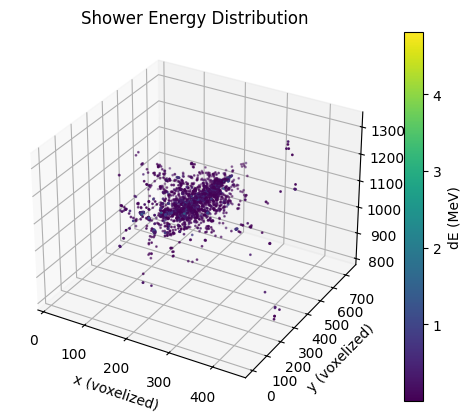

In [24]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(inputs_masked_x,inputs_masked_y,inputs_masked_z,c=inputs_masked_dE, cmap='viridis', s=1)
ax.set_xlabel('x (voxelized)')
ax.set_ylabel('y (voxelized)')
ax.set_zlabel('z (voxelized)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

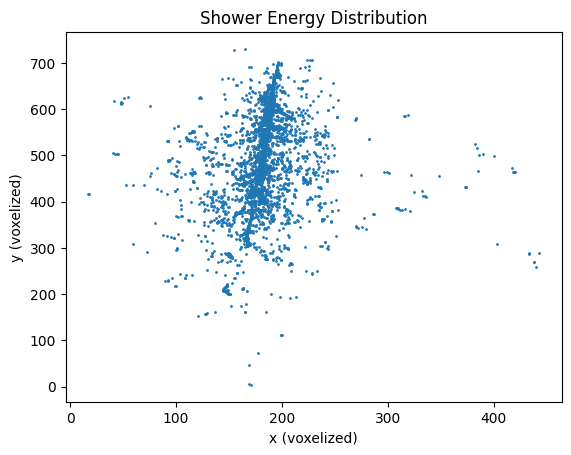

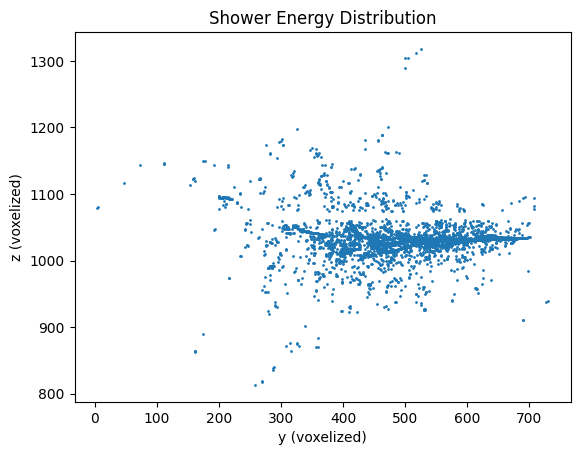

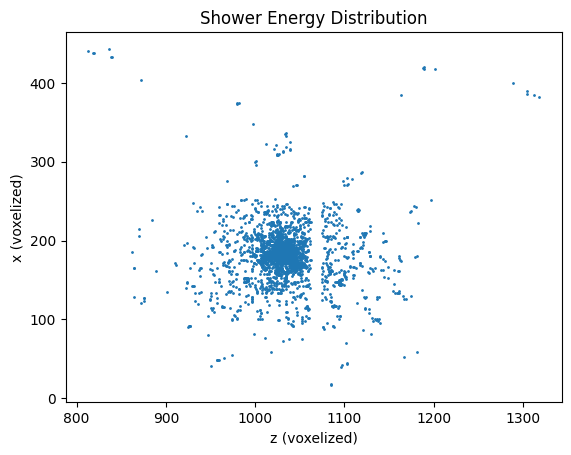

In [25]:
fig = plt.figure()
#ax = fig.add_subplot(projection='3d')

plt.scatter(inputs_masked_x,inputs_masked_y,s=1)
plt.xlabel('x (voxelized)')
plt.ylabel('y (voxelized)')
plt.title('Shower Energy Distribution')
plt.show()

plt.scatter(inputs_masked_y,inputs_masked_z,s=1)
plt.xlabel('y (voxelized)')
plt.ylabel('z (voxelized)')
plt.title('Shower Energy Distribution')
plt.show()

plt.scatter(inputs_masked_z,inputs_masked_x,s=1)
plt.xlabel('z (voxelized)')
plt.ylabel('x (voxelized)')
plt.title('Shower Energy Distribution')
plt.show()

In [5]:
import sys
import importlib
import types
import ROOT
print(types.ModuleType("ROOT"))
#for module in sys.modules:
#    #print("Module:", module)
#    if module == "ROOT":
#        #print(getattr("ROOT", "__spec__", None))
#        print(importlib.util.find_spec("ROOT"))

print("spec:", ROOT.__spec__)
print("file:", getattr(ROOT, "__file__", None))
print("loader:", getattr(ROOT, "__loader__", None))
print("in sys.modules:", "ROOT" in sys.modules)
print(isinstance(ROOT, types.ModuleType))
print(ROOT.gROOT.GetVersion())

<module 'ROOT'>
spec: None
file: /opt/root/lib/ROOT/__init__.py
loader: <_frozen_importlib_external.SourceFileLoader object at 0x7fc8107de530>
in sys.modules: True
True
6.32.02


In [2]:
# Access LARCV dataset
import yaml
#import ROOT
# Method to get list of files in dataset directory
cfg = """
    input_data:
        parser: sparse3d
        sparse_event: sparse3d_pcluster
    particles:
        parser: particle
        particle_event: particle_pcluster
        sparse_event: sparse3d_pcluster
    meta:
        parser: meta
        sparse_event: sparse3d_pcluster"""
cfg = yaml.safe_load(cfg)
file_list = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/electron_NDLAr_10MeVto15GeV_1008TEST.2004.LARCV.root'
larcv_dataset = LArCVDataset(file_keys=file_list, schema=cfg, dtype="float32")
object = larcv_dataset[0]
print(object)


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [3]:
object = larcv_dataset[0]
print(object.keys())
print(len(larcv_dataset))

dict_keys(['index', 'file_index', 'file_entry_index', 'source_file_name', 'source_file_entry_index', 'source_file_size', 'source_file_mtime_ns', 'input_data', 'particles', 'meta'])
50


In [3]:
# Look at hdf5 file
h5_file = h5py.File('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_1008TEST.2001.LARCV.hdf5', 'r')
h5_file.keys()

<KeysViewHDF5 ['ke_initial', 'voxels_flat', 'voxels_offsets']>

In [21]:
import numpy as np 

event_idx = 6

vx_start = int(h5_file['voxels_offsets'][event_idx])
vx_end = int(h5_file['voxels_offsets'][event_idx + 1])

event_vx = h5_file['voxels_flat'][vx_start:vx_end]
ke = h5_file['ke_initial'][event_idx]

print("Event index:", event_idx)
print("Initial kinetic energy:", ke)
print("Number of voxels in event:", len(event_vx))
print("First 10 voxels (x, y, z, dE):")
for i in range(min(10, len(event_vx))):
    print(f"  {i}: ({event_vx[i][0]}, {event_vx[i][1]}, {event_vx[i][2]}, {event_vx[i][3]})")
print("Sum of energy:", np.sum(event_vx[:, 3]))  # Sum of dE values
positions_cm = event_vx[:, :3]  # Get the positions in cm
energy_per_voxel = event_vx[:, 3]  # Get the energy per voxel
print("Positions (cm):", positions_cm[:10])  # Print first 10 positions
print("Energy per voxel (MeV):", energy_per_voxel[:10])  #
print("Number of events:", h5_file.attrs['n_events'])

Event index: 6
Initial kinetic energy: 7705.8706
Number of voxels in event: 15750
First 10 voxels (x, y, z, dE):
  0: (127.22731018066406, -706.8190307617188, -2070.235595703125, 0.00289361784234643)
  1: (194.18910217285156, -669.6180419921875, -2035.2666015625, 0.0014102994464337826)
  2: (40.92100143432617, -749.6001586914062, -1780.4398193359375, 0.00017645856132730842)
  3: (1.4879448413848877, -722.0714111328125, -1669.208740234375, 0.0011436042841523886)
  4: (80.72606658935547, -765.224609375, -1534.169189453125, 0.0011844048276543617)
  5: (-342.62127685546875, 111.97490692138672, -513.0018310546875, 0.001824927981942892)
  6: (-339.64520263671875, 145.0837860107422, -506.3056640625, 0.0005377611960284412)
  7: (-154.75624084472656, -13.0204439163208, -411.07110595703125, 0.0011301222257316113)
  8: (-296.8640441894531, -214.64984130859375, -262.2671203613281, 0.0011180469300597906)
  9: (-229.15823364257812, -254.4549102783203, -258.1750183105469, 0.0010198283707723022)
Sum o